In [1]:
# --- Import libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Import statistic libraries
import scipy.stats as stats
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence

# --- Import metrics libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [2]:
df = pd.read_csv("data/Life Expectancy Data.csv")

In [3]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [5]:
categorical_variables = [col for col in df.columns if df[col].dtype == "object"]
numerical_variables = [col for col in df.columns if df[col].dtype in ["int64", "float64"]]

In [6]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Từ bảng thống kê mô tả, ta có thể rút ra một số nhận xét quan trọng về dữ liệu như sau:
1. **Vấn đề thiếu dữ liệu (Missing values)**: Từ hàng `count` ta có thể thấy rằng tổng số dòng tối đa là **2938** dòng. Tuy nhiên, nhiều cột có số lượng ít hơn hẳn:
   - Cột `Population` chỉ có **2286** giá trị, tức là có **652** giá trị bị thiếu.
   - Cột `Hepatitis B` chỉ có **2385** giá trị (thiếu nhiều).
   - Cột `GDP` chỉ có **2490** giá trị (thiếu nhiều).
   - `Schooling`, `Income composition of resources`: $\sim$ **2770** giá trị.

   Điều này cho thấy rằng dữ liệu không đầy đủ và cần phải xử lý các giá trị thiếu này trước khi tiến hành phân tích sâu hơn.

2. **Sự chênh lệch giàu nghèo cực lớn (Skewness)**: So sánh giữa `mean` và `median` cho thấy:
   - Cột `GDP`: Mean (7483) > Median (1766), cho thấy sự chênh lệch lớn giữa các quốc gia giàu và nghèo.
   - Cột `Measles` (Bệnh sởi): Mean (2419) >> Median (17), đa số các nước kiểm soát tốt sởi (17 ca), nhưng có vài nước bùng dịch khủng khiếp (Max = 212,183 ca). Bên cạnh đó còn một số biến khác tương tự có sự sai khác lớn giữa Mean và Median. Cần biến đổi Logarith chúng.

   Điều này gợi ý rằng có một số quốc gia rất giàu có kéo trung bình lên cao, trong khi phần lớn các quốc gia còn lại có mức sống thấp hơn nhiều.

3. **Các giá trị ngoại lai cực đoan (Extreme Outliers)**: Nhìn vào dòng `max`:
   - `Adult Mortality` max = 723: đây là tỷ lệ tử vong cực cao (72%), có thể do chiến tranh hoặc dịch bệnh tại một thời điểm cụ thể.
   - `HIV/AIDS` max = 50.6:  Nghĩa là 50.6% dân số (hoặc nhóm nguy cơ) nhiễm HIV. Con số này rất cao so với trung bình (1.74), phản ánh thảm họa dịch bệnh tại một số nước Châu Phi.
   - `infant deaths` max = 1800: Đây là số ca đếm được (count), không phải tỷ lệ. Các nước đông dân như Ấn Độ/Trung Quốc sẽ có số này rất to.

4. **Các giá trị "đáng ngờ" hoặc Lỗi dữ liệu (Data Errors)**: Nhìn vào dòng min và max:
   - `BMI` (Chỉ số cơ thể): Min = 1.0: Đây là LỖI. BMI của con người không thể là 1 (sẽ chết vì suy dinh dưỡng nặng). BMI thấp nhất thường khoảng 10-12. Giá trị 1 này có thể là lỗi nhập liệu. Max = 87.3: Rất cao (béo phì cực độ), nhưng có thể xảy ra ở một số quốc đảo Thái Bình Dương (như Nauru).
   - `Schooling` (Số năm đi học): Min = 0: Có thể là nước cực nghèo hoặc dữ liệu thiếu được điền là 0.
   - `GDP`: Min = 1.68: Nếu đơn vị là USD/người thì con số này quá vô lý (quá thấp). Cần kiểm tra lại đơn vị tính hoặc đây là lỗi.

5. **Biến mục tiêu: Tuổi thọ (Life expectancy)**: 
   - Range: Từ 36.3 đến 89.0 tuổi.
   - Mean (69.2) & Median (72.1): Khá gần nhau, cho thấy phân phối của biến mục tiêu tương đối ổn định, không bị lệch quá nhiều như GDP.
   - Min = 36.3: Một mức tuổi thọ rất thấp, phản ánh thảm họa nhân đạo (như trận động đất Haiti 2010 đã kéo tụt tuổi thọ xuống mức này).

# Preprocessing Data

## Missing values

In [7]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness 1-19 years                 34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

Nhóm thiếu ít dữ liệu ($\leq 34$ mẫu): `Life expectancy`, `Adult Mortality`, `BMI`, `Polio`, `Diphtheria`, `thinness 1-19 years`, `thinness 5-9 years`.

Nhóm thiếu dữ liệu ở mức trung bình ($\sim 160$ - $200$ mẫu): `Alcohol`, `Total expenditure`, `Income composition of resources`, `Schooling`.

Nhóm thiếu dữ liệu nhiều ($> 300$ mẫu): `Hepatitis B`, `GDP`, `Population`.

In [8]:
df.dropna(subset=['Life expectancy'], inplace=True)

### Impute missing data bằng chiến lược đa tầng (multi-level imputation strategy)

**Sắp xếp dữ liệu theo chuỗi thời gian**: Vì dữ liệu là số liệu thống kê theo từng năm của các quốc gia, việc sắp xếp theo Quốc gia và Năm là bắt buộc để các phương pháp nội suy (interpolation) hoạt động chính xác dựa trên xu hướng thời gian.

**Nội suy tuyến tính lần 1:** Dữ liệu sẽ được gom nhóm theo từng quốc gia, sau đó áp dụng nội suy tuyến tính (linear interpolation) cho các cột có giá trị thiếu. Phương pháp này sẽ sử dụng các giá trị trước và sau của cùng một quốc gia để ước tính các giá trị bị thiếu, giúp duy trì xu hướng thời gian của từng quốc gia.

In [9]:
df.sort_values(by=["Country", "Year"], inplace=True)

cols_to_fill = df.columns.drop(["Country", "Year", "Status"])
for col in cols_to_fill:
    df[col] = df.groupby("Country")[col].transform(lambda x: x.interpolate())
    
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                             16
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 32
under-five deaths                    0
Polio                               19
Total expenditure                   47
Diphtheria                          19
HIV/AIDS                             0
GDP                                426
Population                         640
thinness 1-19 years                 32
thinness 5-9 years                  32
Income composition of resources    160
Schooling                          160
dtype: int64

**Xử lý biên - Forward fill và Backward fill:** Sau khi nội suy tuyến tính, vẫn còn một số giá trị bị thiếu ở đầu hoặc cuối chuỗi thời gian của một số quốc gia. Để xử lý các giá trị này, ta sẽ sử dụng phương pháp "forward fill" (ffill) để điền các giá trị bị thiếu ở đầu chuỗi bằng giá trị gần nhất phía sau, và "backward fill" (bfill) để điền các giá trị bị thiếu ở cuối chuỗi bằng giá trị gần nhất phía trước.

Đối với các giá trị bị thiếu nhiều, áp dụng điền bằng Trung vị theo trạng thái phát triển của quốc gia (Developing/Developed) để duy trì tính đại diện của dữ liệu.

In [10]:
# Edge class
cols_to_fix = ['Alcohol', 'BMI', 'thinness 1-19 years', 'Total expenditure']
for col in cols_to_fix:
    if df[col].isnull().sum() > 0:
        df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        
# Missing a lot
missing_cols = ['GDP', 'Population', 'Hepatitis B', 'Income composition of resources', 'Schooling']
for col in missing_cols:
    df[col] = df[col].fillna(df.groupby("Status")[col].transform("median"))
    
df.isnull().sum()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9360\3440089956.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9360\3440089956.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9360\3440089956.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9360\3440089956.py:5: FutureWarning

Country                             0
Year                                0
Status                              0
Life expectancy                     0
Adult Mortality                     0
infant deaths                       0
Alcohol                            16
percentage expenditure              0
Hepatitis B                         0
Measles                             0
BMI                                32
under-five deaths                   0
Polio                              19
Total expenditure                  32
Diphtheria                         19
HIV/AIDS                            0
GDP                                 0
Population                          0
thinness 1-19 years                32
thinness 5-9 years                 32
Income composition of resources     0
Schooling                           0
dtype: int64

Đối với các dữ liệu còn thiếu sau các bước trên, áp dụng điền bằng trung vị toàn cục

In [11]:
remaining_missing_cols = ['Alcohol', 'BMI', 'Total expenditure', 'Polio', 'Diphtheria', 'thinness 1-19 years', 'thinness 5-9 years']
for col in remaining_missing_cols:
    # ffill: lấy năm trước điền cho năm sau
    df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(method='ffill'))
    # bfill: lấy năm sau điền cho năm trước (nếu năm đầu bị thiếu)
    df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(method='bfill'))
    
if df.isnull().sum().sum() > 0:
    df.fillna(df.median(numeric_only=True), inplace=True)
    
df.isnull().sum()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9360\2691094994.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(method='ffill'))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9360\2691094994.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(method='bfill'))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9360\2691094994.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(method='ffill'))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9360\2691094994.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a futur

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness 1-19 years                0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

In [12]:
df = df.drop('Year', axis=1)

In [65]:
df.describe()

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Encoded
count,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000,2.793000e+03,2793.000000,2793.000000,2793.000000,2793.000000,2793.000000
mean,69.502828,157.549588,29.901898,4.595849,766.315148,83.217329,1026.265664,39.992266,41.507698,82.654493,5.969230,82.288579,1.110956,7009.348452,1.035038e+07,4.737272,4.738310,0.636621,12.137630,0.182241
std,9.464848,109.145541,119.426521,4.093709,2032.187801,22.755231,2522.169910,18.723386,162.470458,23.169563,2.507246,23.703709,2.200533,13591.155570,5.511147e+07,4.413797,4.455824,0.207211,3.298841,0.386112
min,36.300000,1.000000,0.000000,0.010000,0.000000,9.000000,0.000000,5.000000,0.000000,9.000000,0.370000,9.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000,0.000000
25%,63.700000,74.000000,0.000000,0.710000,5.234770,83.000000,0.000000,21.900000,0.000000,78.000000,4.290000,78.000000,0.100000,572.143130,4.124770e+05,1.600000,1.500000,0.511000,10.300000,0.000000
50%,72.400000,142.000000,3.000000,3.690000,67.762691,91.000000,17.000000,44.700000,4.000000,93.000000,5.760000,93.000000,0.100000,1367.352433,1.396923e+06,3.300000,3.300000,0.680000,12.400000,0.000000
75%,75.900000,225.000000,21.000000,7.820000,463.639782,96.000000,352.000000,56.400000,26.000000,97.000000,7.530000,97.000000,0.700000,5676.141430,4.646646e+06,7.000000,6.900000,0.785000,14.400000,0.000000
max,89.000000,399.000000,1800.000000,17.870000,19479.911610,99.000000,10000.000000,77.600000,2500.000000,99.000000,17.600000,99.000000,8.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000,1.000000


## Outliers

Áp dụng phương pháp Winsorizing để xử lý giá trị ngoại lại trong các biến số liên tục, giới hạn giá trị trong khoảng [5%, 95%].

In [13]:
df['HIV/AIDS'] = winsorize(df['HIV/AIDS'], limits=[0, 0.05])
df['Adult Mortality'] = winsorize(df['Adult Mortality'], limits=[0, 0.05])
df['Measles'] = winsorize(df['Measles'], limits=[0, 0.05])

df['Hepatitis B'] = winsorize(df['Hepatitis B'], limits=[0.05, 0])
df['Polio'] = winsorize(df['Polio'], limits=[0.05, 0])
df['Diphtheria'] = winsorize(df['Diphtheria'], limits=[0.05, 0])

In [17]:
df = df[df['BMI'] >=5]

In [20]:
numerical_variables = [col for col in df.columns if df[col].dtype in ["int64", "float64"]]

In [21]:
len(numerical_variables)

19

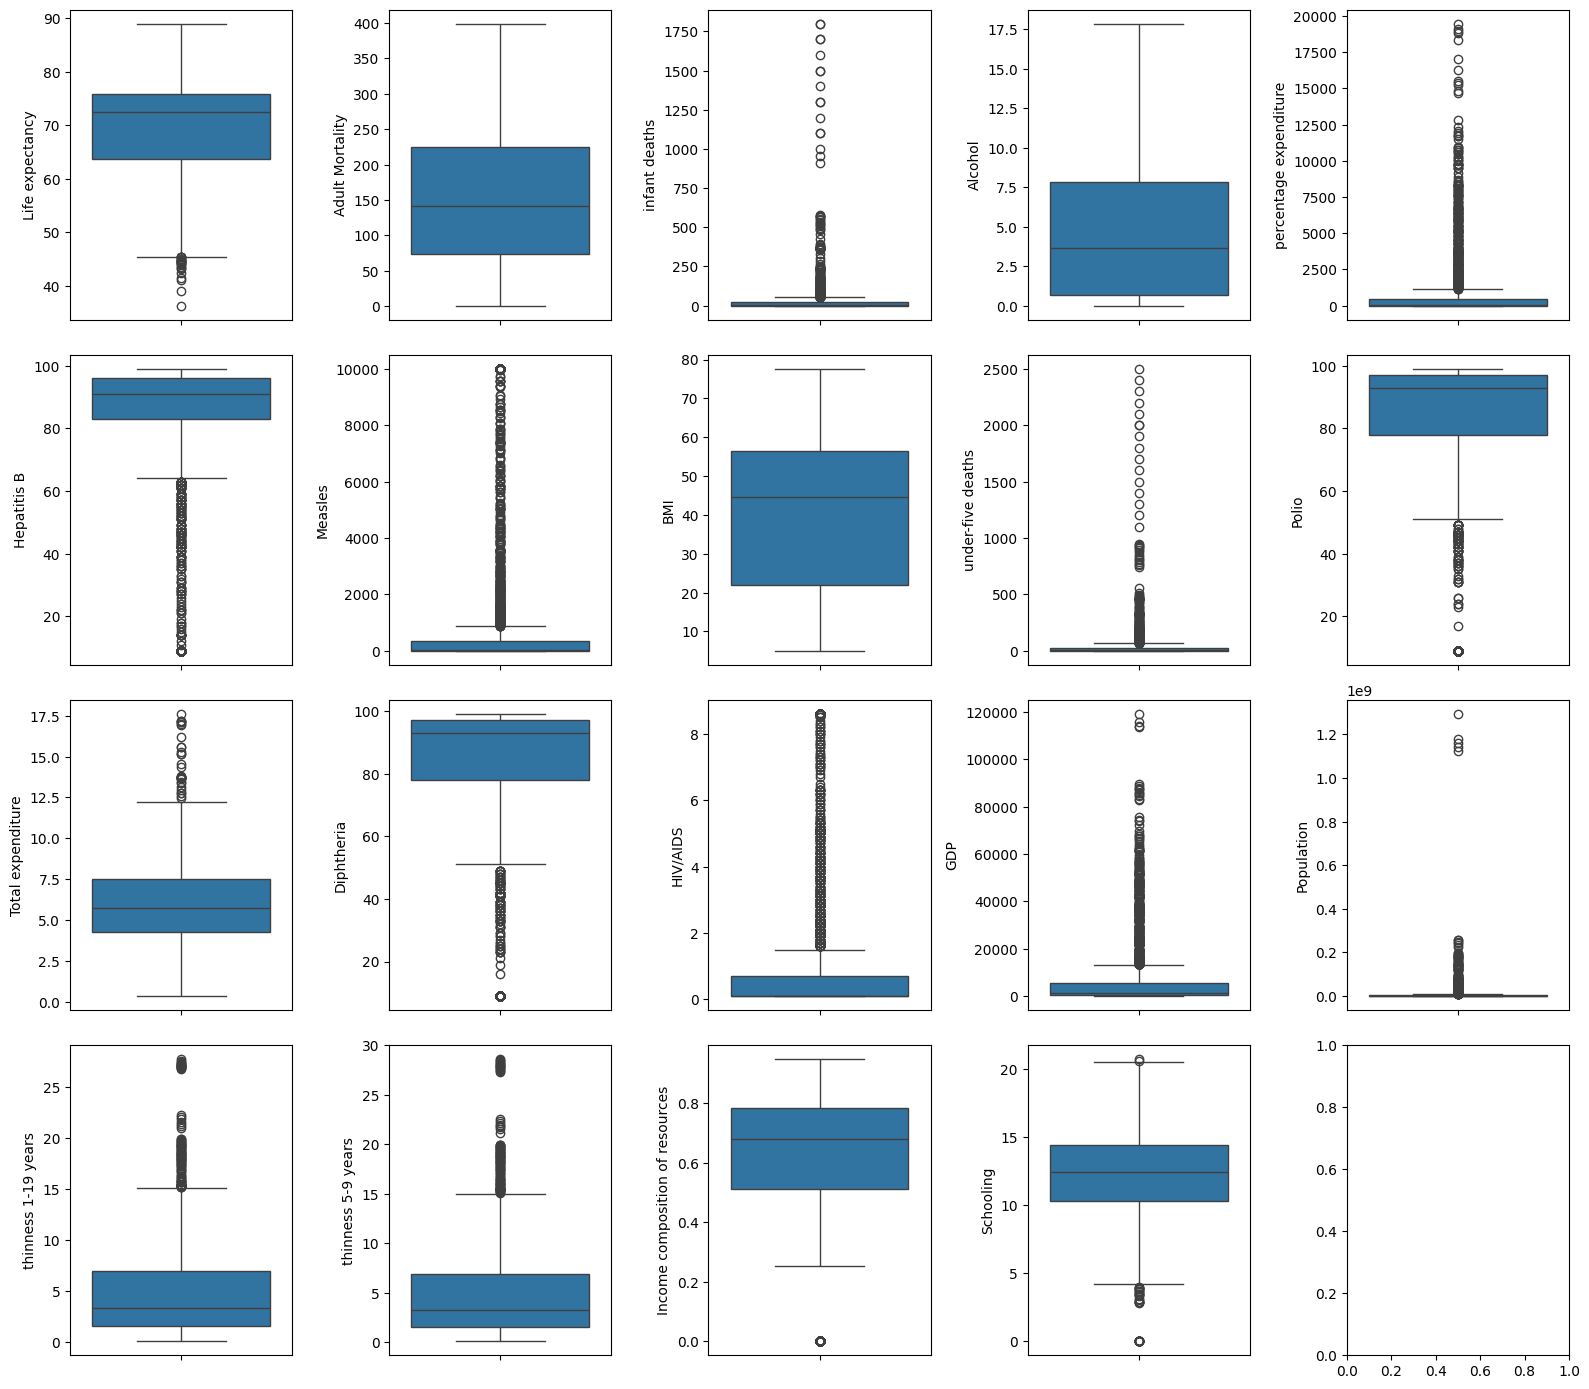

In [22]:
fig, axes = plt.subplots(4, 5, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_variables):
    sns.boxplot(df[col], ax=axes[i])

plt.tight_layout()
plt.show()

In [23]:
df.shape

(2793, 21)

# Multicollinearity

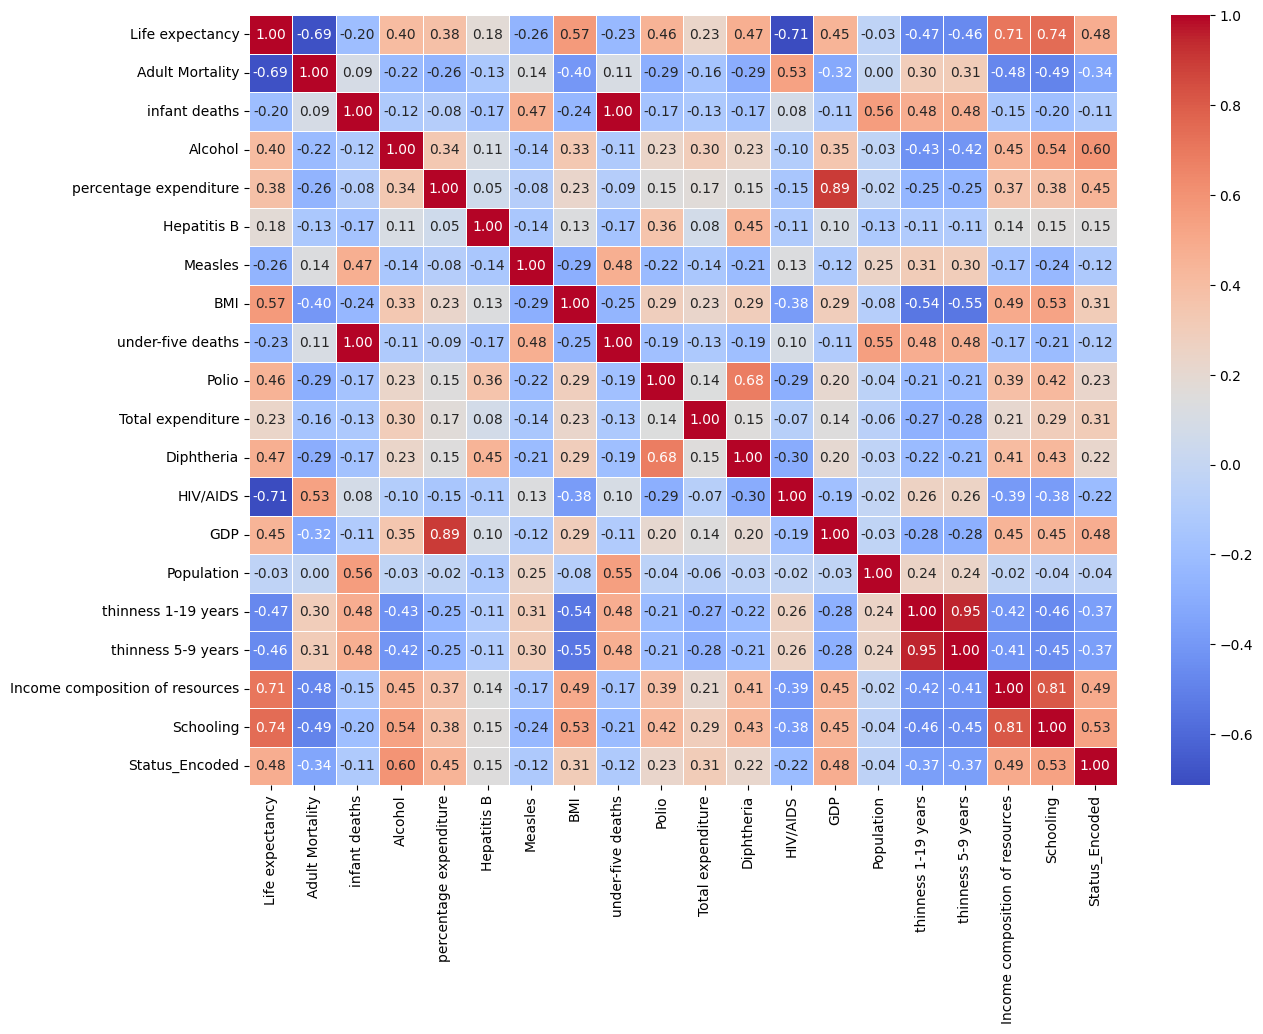

In [24]:
df['Status_Encoded'] = df['Status'].apply(lambda x: 1 if x == 'Developed' else 0)
df = df.drop(["Country", "Status"], axis=1)

corr_matrix = df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", fmt=".2f", annot=True, linewidths=0.5)
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9360\481717418.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette=colors)


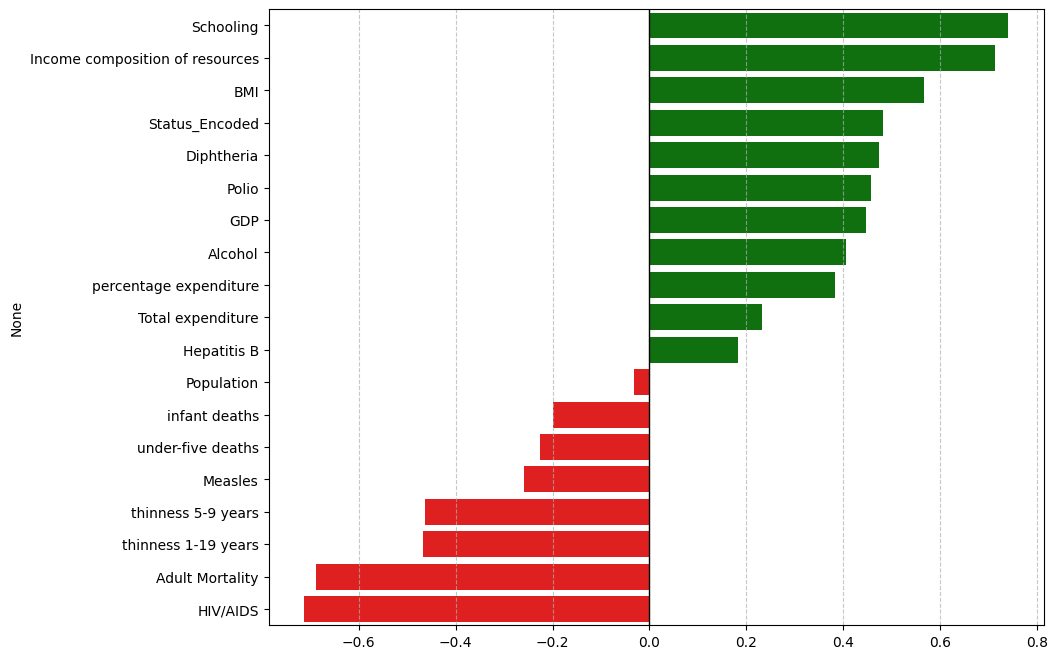

In [25]:
target_col = "Life expectancy"
corr_with_target = corr_matrix[target_col]
corr_with_target = corr_with_target.drop(target_col)
corr_with_target = corr_with_target.sort_values(ascending=False)
plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in corr_with_target.values]
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette=colors)
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [26]:
cols_to_drop = [
    'infant deaths', 
    'percentage expenditure', 
    'thinness 5-9 years', 
    'Income composition of resources',
    'Population', # Loại vì không có tương quan với target
    'Hepatitis B', # Tương quan yếu
]

df_clean = df.drop(columns=cols_to_drop)

In [27]:
df_clean.head()

,Life expectancy,Adult Mortality,Alcohol,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 1-19 years,Schooling,Status_Encoded
15,54.8,321.0,0.01,6532,12.2,122,24.0,8.20,24.0,0.1,114.560000,2.3,5.5,0
14,55.3,316.0,0.01,8762,12.6,122,35.0,7.80,33.0,0.1,117.496980,2.1,5.9,0
13,56.2,3.0,0.01,2486,13.0,122,36.0,7.76,36.0,0.1,187.845950,19.9,6.2,0
12,56.7,295.0,0.01,798,13.4,122,41.0,8.82,41.0,0.1,198.728544,19.7,6.5,0
11,57.0,293.0,0.02,466,13.8,120,9.0,8.79,9.0,0.1,219.141353,19.5,6.8,0


In [28]:
df_clean.shape

(2793, 14)

## Split Data

In [29]:
y = df_clean["Life expectancy"]
X = df_clean.drop("Life expectancy", axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Checking the distribution of independent variables in training and testing sets

In [30]:
X_train.shape

(2234, 13)

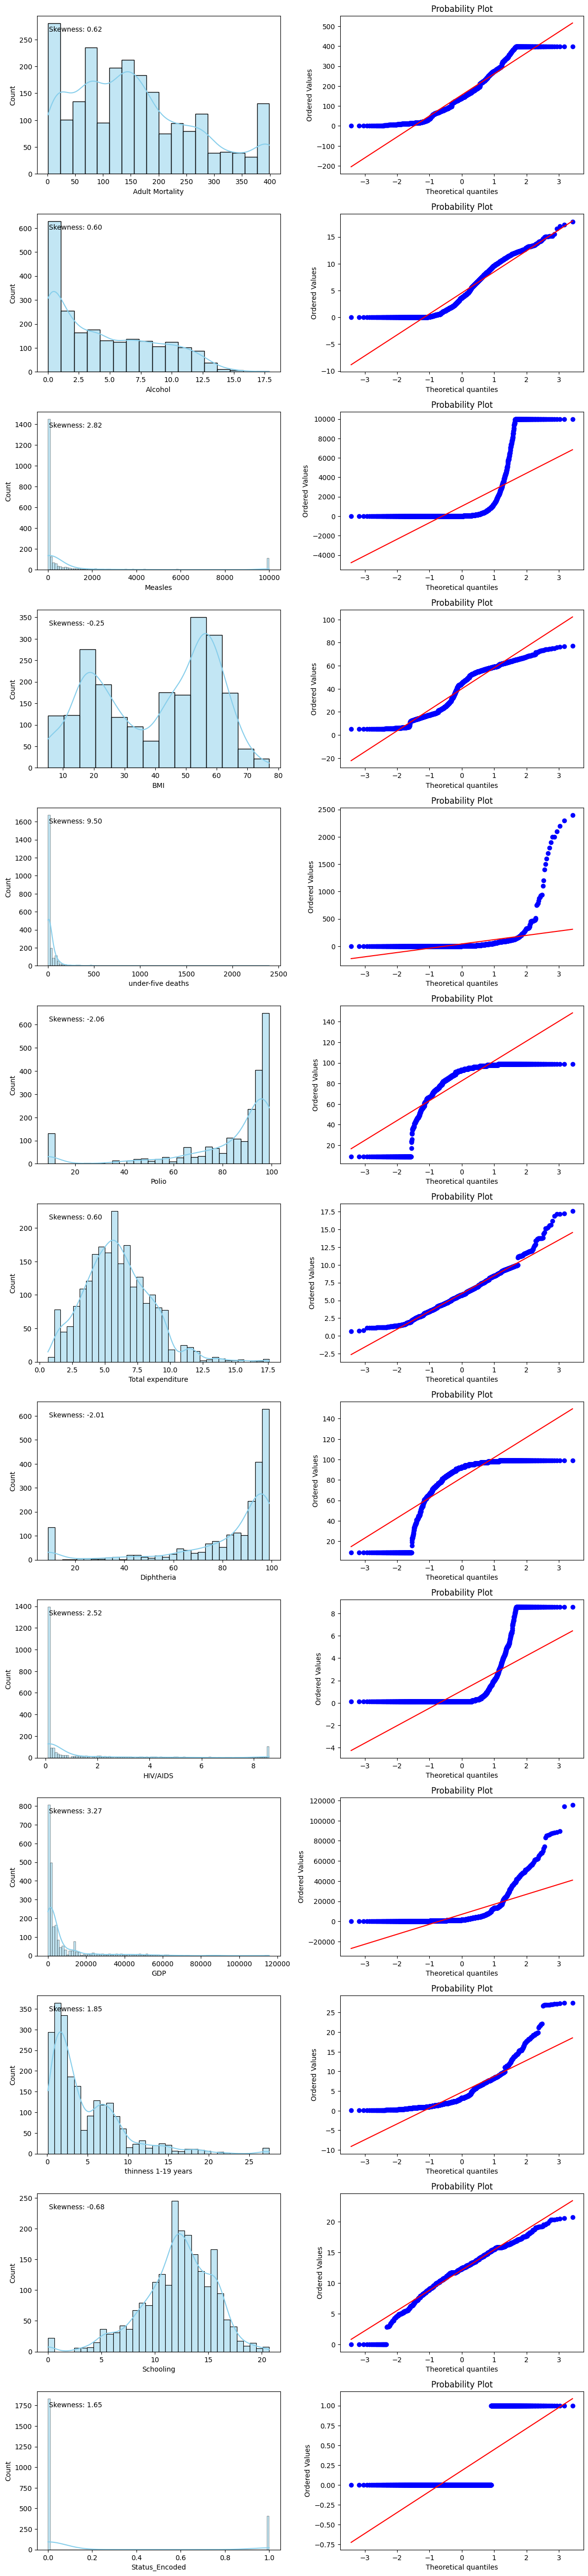

In [32]:
number_of_colums = X_train
n_cols = 3
n_rows = (len(number_of_colums) * 2)

plt.figure(figsize=(12, 2*n_rows))
for i, col in enumerate(number_of_colums):
    # Histogram
    plt.subplot(len(number_of_colums), 2, 2*i + 1)
    sns.histplot(X_train[col], kde=True, color="skyblue")
    
    skewness = X_train[col].skew()
    plt.text(0.05, 0.9, f'Skewness: {skewness:.2f}', transform=plt.gca().transAxes)
    
    # Q-Q plot
    plt.subplot(len(number_of_colums), 2, 2*i + 2)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    
plt.tight_layout()
plt.show()

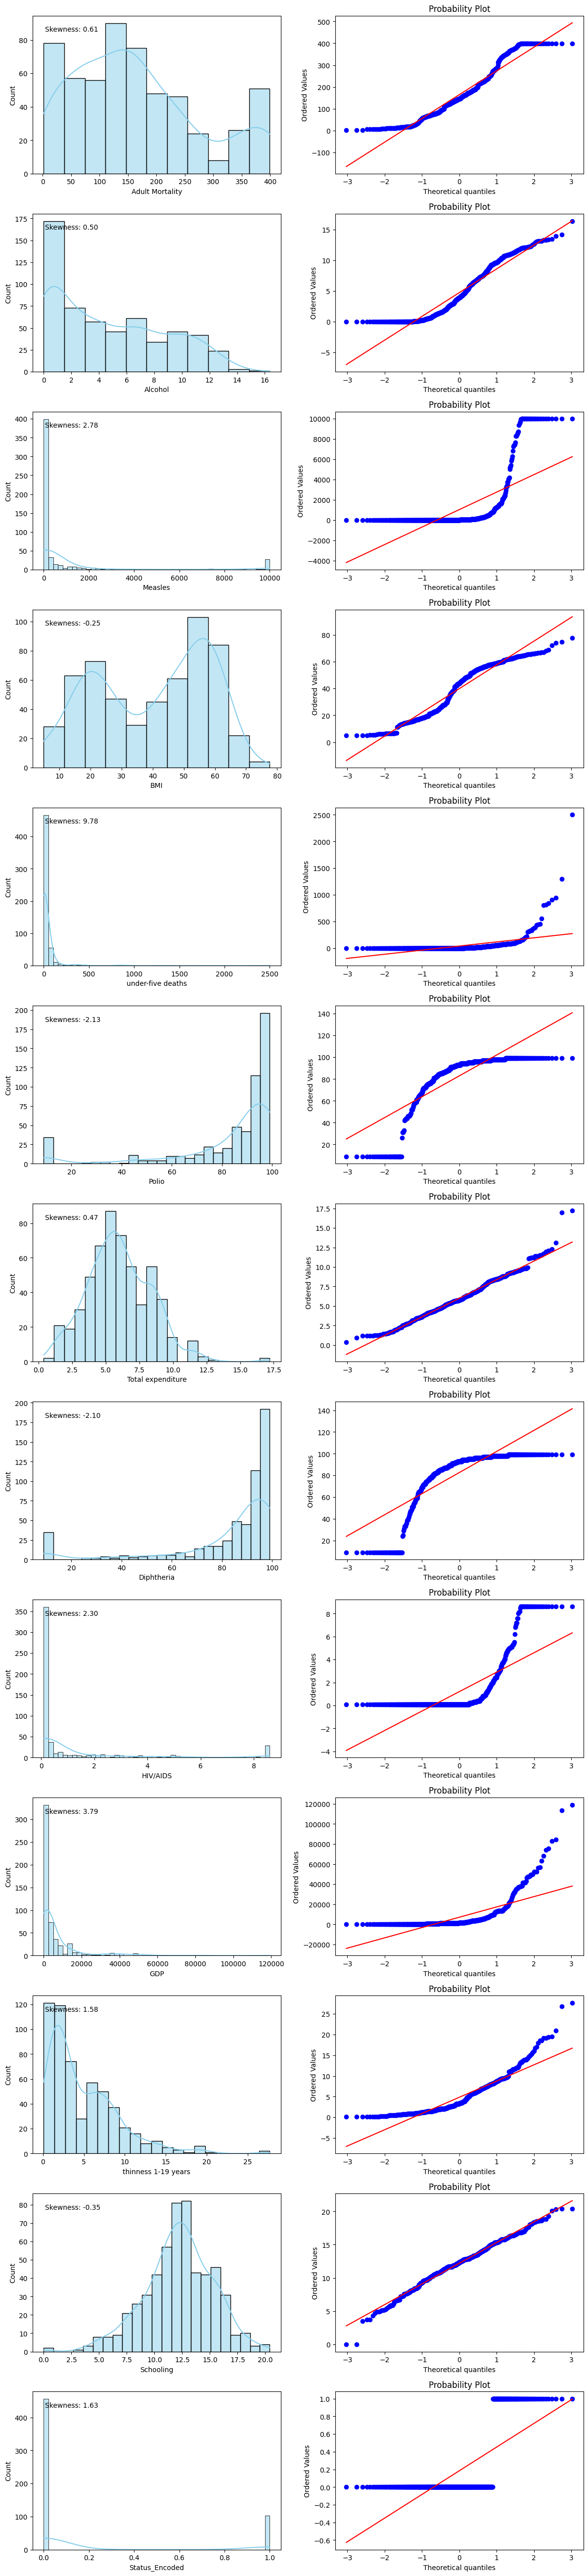

In [33]:
number_of_colums = X_test
n_cols = 3
n_rows = (len(number_of_colums) * 2)

plt.figure(figsize=(12, 2*n_rows))
for i, col in enumerate(number_of_colums):
    # Histogram
    plt.subplot(len(number_of_colums), 2, 2*i + 1)
    sns.histplot(X_test[col], kde=True, color="skyblue")
    
    skewness = X_test[col].skew()
    plt.text(0.05, 0.9, f'Skewness: {skewness:.2f}', transform=plt.gca().transAxes)
    
    # Q-Q plot
    plt.subplot(len(number_of_colums), 2, 2*i + 2)
    stats.probplot(X_test[col], dist="norm", plot=plt)
    
plt.tight_layout()
plt.show()

## Transform Data

Only transform the right skewed features

In [34]:
skewed_cols = ["Measles", "under-five deaths", "HIV/AIDS", "GDP", "thinness 1-19 years"]

for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_train.rename(columns={col: f"Log_{col}"}, inplace=True)
    
    X_test[col] = np.log1p(X_test[col])
    X_test.rename(columns={col: f"Log_{col}"}, inplace=True)

In [35]:
X_train.head()

,Adult Mortality,Alcohol,Log_Measles,BMI,Log_under-five deaths,Polio,Total expenditure,Diphtheria,Log_HIV/AIDS,Log_GDP,Log_thinness 1-19 years,Schooling,Status_Encoded
1532,222.0,12.30,0.693147,58.4,0.000000,93.0,5.83,94.0,0.095310,8.970071,1.386294,16.2,1
2550,135.0,1.25,6.289716,45.3,2.484907,86.0,4.94,84.0,0.095310,7.142143,2.028148,10.2,0
252,95.0,11.28,3.806662,59.4,0.693147,96.0,9.30,95.0,0.095310,8.228165,0.587787,18.6,1
1855,78.0,9.31,3.044522,62.1,0.000000,89.0,8.25,89.0,0.095310,7.929089,0.262364,18.9,1
1774,399.0,1.23,9.210440,18.5,4.770685,71.0,6.87,9.0,2.261763,5.913921,1.589235,7.3,0


Scaling data using StandardScaler

In [36]:
cols_to_scale = [col for col in X_train.columns if col != "Status_Encoded"]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Fitting Models

Create a stepwise selection function for feature selection

In [37]:
def stepwise_selection(X, y, threshold=0.05, verbose=True):
    """
    Parameters:
    -----------
    X : pandas.DataFrame, shape (n_samples, n_features)
        The input features.
    y : pandas.Series, shape (n_samples,)
        The target variable.
    threshold : float, default 0.05
        The p-value threshold for adding and removing features.
    verbose : bool, default True
        Whether to print the sequence of additions and deletions.

    Returns:
    --------
    included : list
        The list of selected features.
    """
    included = []
    while True:
        changed = False
        # Forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, pd.DataFrame(X[included + [new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print(f'Add  {best_feature} with p-value {best_pval:.4f}')

        # Backward step
        model = sm.OLS(y, pd.DataFrame(X[included])).fit()
        pvalues = model.pvalues.iloc[1:]  # Skip the intercept
        worst_pval = pvalues.max()
        if worst_pval > threshold:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print(f'Drop {worst_feature} with p-value {worst_pval:.4f}')

        if not changed:
            break

    return included

In [38]:
X_train_const = sm.add_constant(X_train_scaled)
accepted_features = stepwise_selection(X_train_const, y_train, threshold=0.05, verbose=True)

Add  const with p-value 0.0000
Add  Log_HIV/AIDS with p-value 0.0000
Add  Schooling with p-value 0.0000
Add  Adult Mortality with p-value 0.0000
Add  Log_under-five deaths with p-value 0.0000
Add  Log_GDP with p-value 0.0000
Add  Diphtheria with p-value 0.0000
Add  Log_thinness 1-19 years with p-value 0.0000
Add  Status_Encoded with p-value 0.0000
Add  Polio with p-value 0.0067


## OLS Model

In [39]:
ols = sm.OLS(np.log1p(y_train), X_train_const[accepted_features]).fit()

In [40]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     1239.
Date:                Thu, 22 Jan 2026   Prob (F-statistic):               0.00
Time:                        11:58:35   Log-Likelihood:                 3181.3
No. Observations:                2234   AIC:                            -6343.
Df Residuals:                    2224   BIC:                            -6286.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [41]:
residuals = ols.resid_pearson
fitted_values = ols.fittedvalues

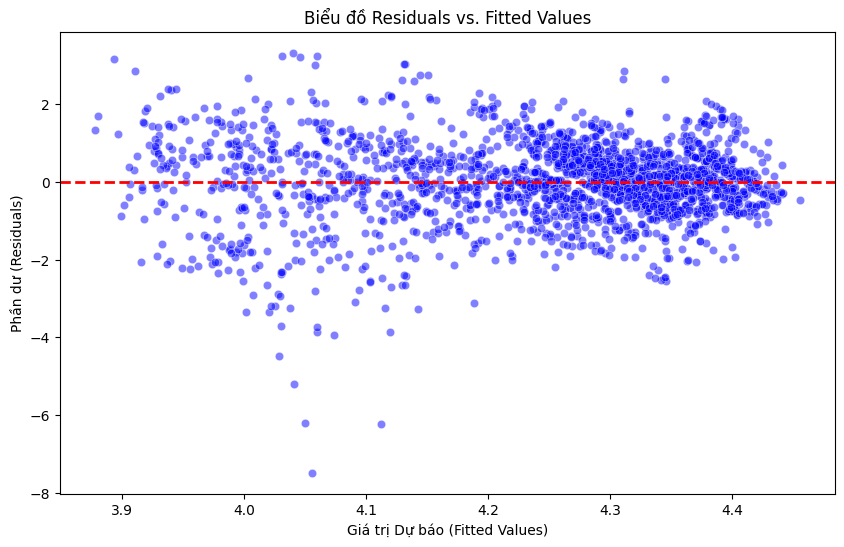

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals, color='blue', alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2) # Đường kẻ ngang tại 0
plt.xlabel('Giá trị Dự báo (Fitted Values)')
plt.ylabel('Phần dư (Residuals)')
plt.title('Biểu đồ Residuals vs. Fitted Values')
plt.show()

## WLS Model

In [45]:
log_resid_sq = np.log(residuals**2)

var_model = sm.OLS(log_resid_sq, X_train_const[accepted_features]).fit()
fitted_vars = np.exp(var_model.fittedvalues)

# Calculate weights
weights = 1 / fitted_vars

# Fitting WLS model
wls_model = sm.WLS(np.log1p(y_train), X_train_const[accepted_features], weights=weights).fit()

In [46]:
print(wls_model.summary())

                            WLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.789
Model:                            WLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     922.1
Date:                Thu, 22 Jan 2026   Prob (F-statistic):               0.00
Time:                        12:00:12   Log-Likelihood:                 3435.0
No. Observations:                2234   AIC:                            -6850.
Df Residuals:                    2224   BIC:                            -6793.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Using Cook's distance to identify influential points and remove them from the training set

In [47]:
wls_influence = OLSInfluence(wls_model)
(c, p) = wls_influence.cooks_distance

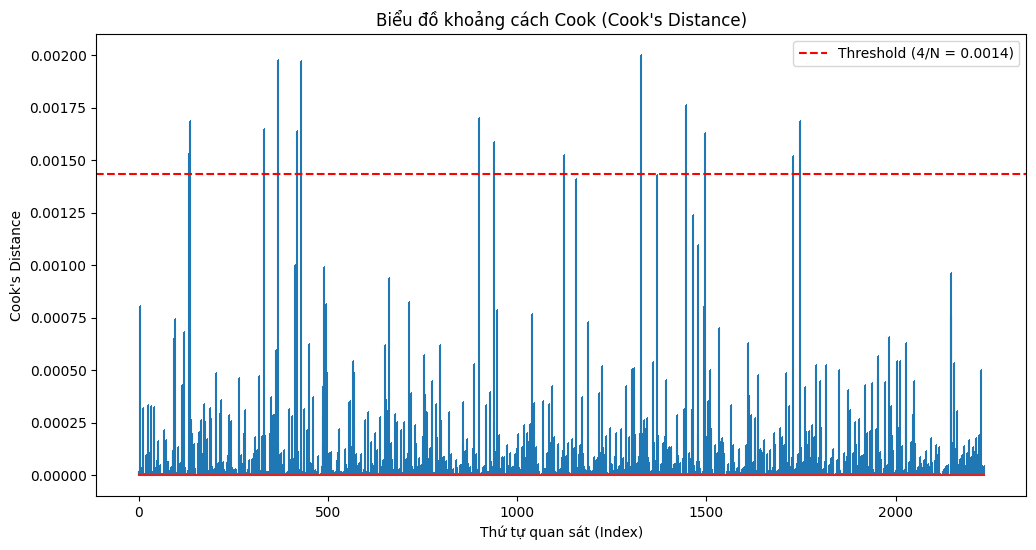

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))
plt.stem(np.arange(len(c)), c, markerfmt=",")
plt.title("Biểu đồ khoảng cách Cook (Cook's Distance)")
plt.xlabel("Thứ tự quan sát (Index)")
plt.ylabel("Cook's Distance")

# Vẽ đường ngưỡng (Threshold) 4/N
n = len(df) # Số lượng quan sát
c_threshold = 4 / n
plt.axhline(y=c_threshold, color='r', linestyle='--', label=f'Threshold (4/N = {c_threshold:.4f})')
plt.legend()
plt.show()

In [49]:
X_train_const["cook's"] = c
X_train_const = X_train_const[X_train_const["cook's"] <= c_threshold]

## Final Model

In [50]:
# Align indices of y_train and X_train_const[accepted_features]
y_train_aligned, X_train_aligned = y_train.align(X_train_const[accepted_features], join='inner', axis=0)

# Fit the WLS model with aligned data
wls_model_final = sm.WLS(np.log1p(y_train_aligned), X_train_aligned, weights=weights.loc[y_train_aligned.index]).fit()
print(wls_model_final.summary())

                            WLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.795
Model:                            WLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     952.9
Date:                Thu, 22 Jan 2026   Prob (F-statistic):               0.00
Time:                        12:00:23   Log-Likelihood:                 3484.4
No. Observations:                2220   AIC:                            -6949.
Df Residuals:                    2210   BIC:                            -6892.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## Check Assumptions

In [51]:
influence_final = OLSInfluence(wls_model_final)
resid_student_internal = influence_final.resid_studentized_internal
fitted_final = wls_model_final.fittedvalues

### Homoscedasticity assumption
Homoscedasticity check using Breusch-Pagan test

In [52]:
bp_test = het_breuschpagan(resid_student_internal, X_train_aligned)
print(bp_test)

(np.float64(350.44412279866964), np.float64(4.984870408946275e-70), np.float64(46.02884691193409), np.float64(2.1950980159862198e-76))


In [53]:
bp_result = pd.DataFrame({
    "LM statistic": [bp_test[0]],
    "LM p-value": [bp_test[1]],
    "F-statistic": [bp_test[2]],
    "F p-value": [bp_test[3]]
})

bp_result.round(5)

,LM statistic,LM p-value,F-statistic,F p-value
0,350.44412,0.0,46.02885,0.0


**Giả thuyết - Đối thuyết kiểm định Breusch-Pagan**:
- $H_0$: Phương sai của sai số là hằng định (không có hiện tượng phương sai thay đổi).
- $H_1$: Phương sai của sai số không phải là hằng định (có hiện tượng phương sai thay đổi).

Với mức ý nghĩa $\alpha = 0.05$, ta so sánh p-value với $\alpha$ để đưa ra kết luận:
- Nếu p-value > $\alpha$: Không đủ bằng chứng để bác bỏ $H_0$. Phương sai của sai số được coi là hằng định (không có hiện tượng phương sai thay đổi).
- Nếu p-value ≤ $\alpha$: Bác bỏ $H_0$. Phương sai của sai số không phải là hằng định (có hiện tượng phương sai thay đổi).

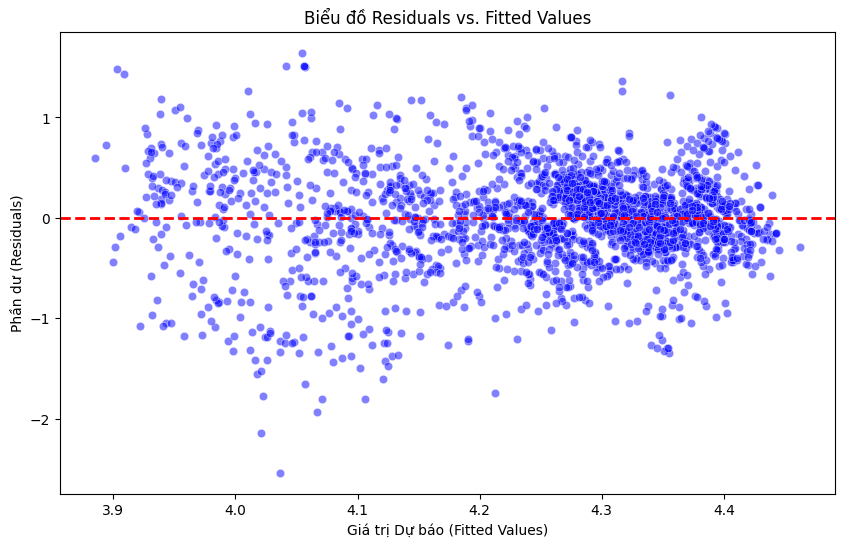

In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_final, y=resid_student_internal, color='blue', alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2) # Đường kẻ ngang tại 0
plt.xlabel('Giá trị Dự báo (Fitted Values)')
plt.ylabel('Phần dư (Residuals)')
plt.title('Biểu đồ Residuals vs. Fitted Values')
plt.show()

### Normality assumption

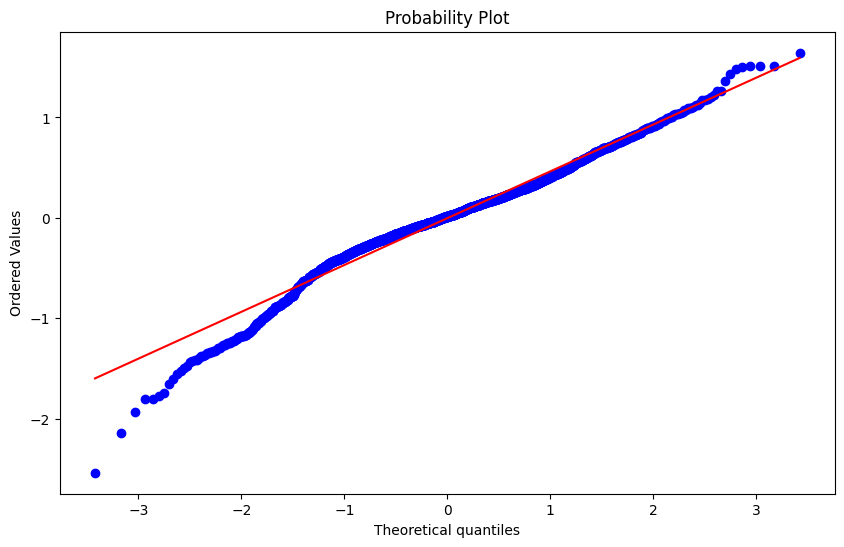

In [55]:
plt.figure(figsize=(10, 6))
stats.probplot(resid_student_internal, dist="norm", plot=plt)
plt.show()

Sử dụng hệ số tương quan $r_Q$ để kiểm tra giả thuyết về phân phối chuẩn của phần dư trong mô hình hồi quy.

**Bước 1: Sắp xếp phần dư:** Sắp xếp phần dư từ nhỏ đến lớn để có được dãy phần dư đã sắp xếp.
$$e_{(1)} \leq e_{(2)} \leq \ldots \leq e_{(n)}$$

**Bước 2: Tính phân vị chuẩn lý thuyết:** tính giá trị phân vị tương ứng từ phân phối chuẩn tắc $Z \sim \mathcal{N}(0,1)$.

**Bước 3: Tính hệ số tương quan $r_Q$** giữa các phần dư đã sắp xếp và các phân vị chuẩn lý thuyết tương ứng.

In [56]:
def calculate_rQ(residuals):
    # Step 1
    sorted_residuals = np.sort(residuals)
    n = len(sorted_residuals)
    
    # Step 2
    plotting_position = (np.arange(1, n + 1) - 0.5) / n
    theoretical_quantiles = stats.norm.ppf(plotting_position)
    
    # Step 3
    rQ = stats.pearsonr(sorted_residuals, theoretical_quantiles)
    
    return rQ

In [57]:
r_Q = calculate_rQ(resid_student_internal)
r_Q

PearsonRResult(statistic=np.float64(0.9863684883163377), pvalue=np.float64(0.0))

In [58]:
# Giá trị tới hạn
print(stats.norm.ppf(1 - 0.05/2))

1.959963984540054


Với giá trị tới hạn $z_{1 - \alpha/2} = 1.95 > r_Q = 0.993$, phần dư không tuân theo phân phối chuẩn (từ Q-Q plot cũng thấy rõ điều này).

# Đánh giá trên tập Test

In [59]:
X_test_const = sm.add_constant(X_test_scaled)
y_pred = wls_model_final.predict(X_test_const[wls_model_final.model.exog_names])

Evaluation metrics on the test set

In [60]:
y_pred_org = np.expm1(y_pred)

# R2
r2 = r2_score(y_test, y_pred_org)

# R2 adj
n_test = X_test_const[wls_model_final.model.exog_names].shape[0]
p_test = len(wls_model_final.model.exog_names) - 1
adj_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - p_test - 1)

# Mean absolute error
mae = mean_absolute_error(y_test, y_pred_org)

# Mean absolute percentage error
mape = mean_absolute_percentage_error(y_test, y_pred_org)

# Root mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred_org))

In [61]:
print(f"R2 trên test: {r2:.4f}")
print(f"R2 hiệu chỉnh trên test: {adj_r2:.4f}")
print(f"MAE trên test: {mae:.4f}")
print(f"MAPE trên test: {mape:.4f}")
print(f"RMSE trên test: {rmse:.4f}")

R2 trên test: 0.8564
R2 hiệu chỉnh trên test: 0.8540
MAE trên test: 2.7513
MAPE trên test: 0.0417
RMSE trên test: 3.6669


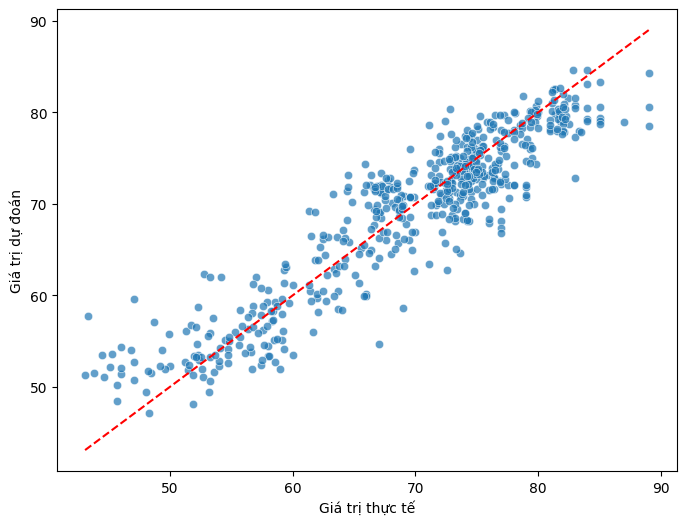

In [52]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_org, alpha=0.7)
min_val = min(min(y_test), min(y_pred_org))
max_val = max(max(y_test), max(y_pred_org))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.show()

# Đưa ra khoảng dự báo 95%

In [62]:
example_df = X_test.sample(n=1, random_state=42).reset_index(drop=True)
example_df

,Adult Mortality,Alcohol,Log_Measles,BMI,Log_under-five deaths,Polio,Total expenditure,Diphtheria,Log_HIV/AIDS,Log_GDP,Log_thinness 1-19 years,Schooling,Status_Encoded
0,163.0,10.49,3.332205,52.1,0.693147,92.0,1.5,9.0,0.09531,7.114631,1.308333,11.7,0


Thực hiện dự đoán

In [63]:
# Chuẩn hóa dữ liệu
example_df_scaled = example_df.copy()
example_df_scaled[cols_to_scale] = scaler.transform(example_df[cols_to_scale])

# Convert scaled data back to a DataFrame with appropriate column names
example_df_scaled_df = pd.DataFrame(example_df_scaled, columns=example_df_scaled.columns)

# Add a constant column for the intercept
example_df_const = sm.add_constant(example_df_scaled_df, has_constant='add')

# Get predictions
predict_sample = wls_model_final.get_prediction(example_df_const[wls_model_final.model.exog_names])

# Extract the prediction summary frame
prediction_summary = predict_sample.summary_frame(alpha=0.05)

# Apply np.expm1 to the mean predictions and confidence intervals
prediction_summary['mean'] = np.expm1(prediction_summary['mean'])
prediction_summary['mean_ci_lower'] = np.expm1(prediction_summary['mean_ci_lower'])
prediction_summary['mean_ci_upper'] = np.expm1(prediction_summary['mean_ci_upper'])
prediction_summary['obs_ci_lower'] = np.expm1(prediction_summary['obs_ci_lower'])
prediction_summary['obs_ci_upper'] = np.expm1(prediction_summary['obs_ci_upper'])

print("Dự báo cho một mẫu dữ liệu trên Test:")
prediction_summary

Dự báo cho một mẫu dữ liệu trên Test:


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,68.960049,0.006337,68.095973,69.83493,54.500476,87.186783


Diễn giải kết quả dự đoán

In [64]:
predict_value = prediction_summary['mean'][0]
conf_int_mean_lower = prediction_summary['mean_ci_lower'][0]
conf_int_mean_upper = prediction_summary['mean_ci_upper'][0]
pred_int_obs_lower = prediction_summary['obs_ci_lower'][0]
pred_int_obs_upper = prediction_summary['obs_ci_upper'][0]

print(f"Tuổi thọ dự đoán dựa trên mẫu: {predict_value:.4f}")
print(f"Khoảng tin cậy 95% cho giá trị trung bình của tuổi thọ: ({conf_int_mean_lower:.4f}, {conf_int_mean_upper:.4f})")
print(f"Khoảng dự đoán 95% cho tuổi thọ dự đoán dựa trên mẫu: ({pred_int_obs_lower:.4f}, {pred_int_obs_upper:.4f})")

Tuổi thọ dự đoán dựa trên mẫu: 68.9600
Khoảng tin cậy 95% cho giá trị trung bình của tuổi thọ: (68.0960, 69.8349)
Khoảng dự đoán 95% cho tuổi thọ dự đoán dựa trên mẫu: (54.5005, 87.1868)
